<a href="https://colab.research.google.com/github/Deepakmittal03/Sales_Performance_Analysis/blob/main/Sales_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Shape : (9800, 18)

Columns :
Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

Missing Values
Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64

Summary Statistics
            Row_ID   Postal_Code         Sales
count  9800.000000   9789.000000   9800.000000
mean   4900.500000  55273.322403    230.769059
std    2829.160653  32041.223413    626.651875
min       1.000000   1040.000000      0.444000
25%    2450.750000  23223.000000     17.248000
50%

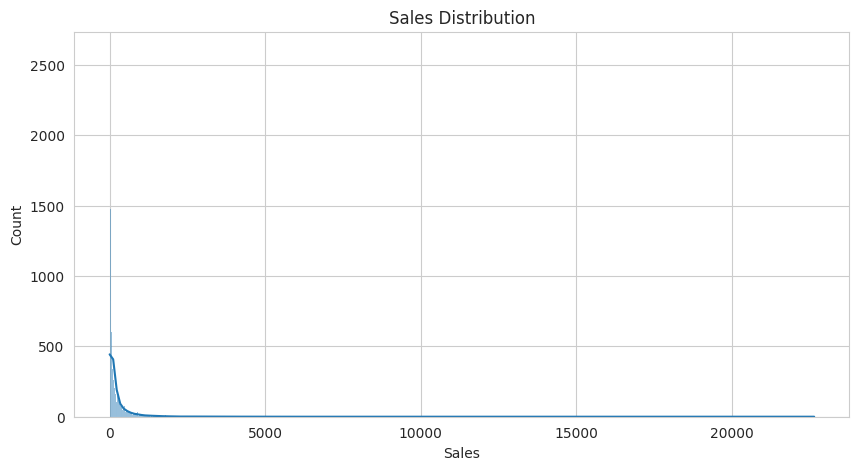

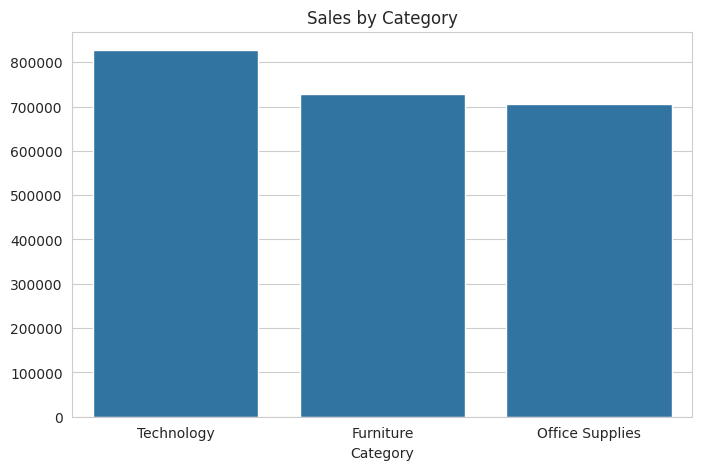

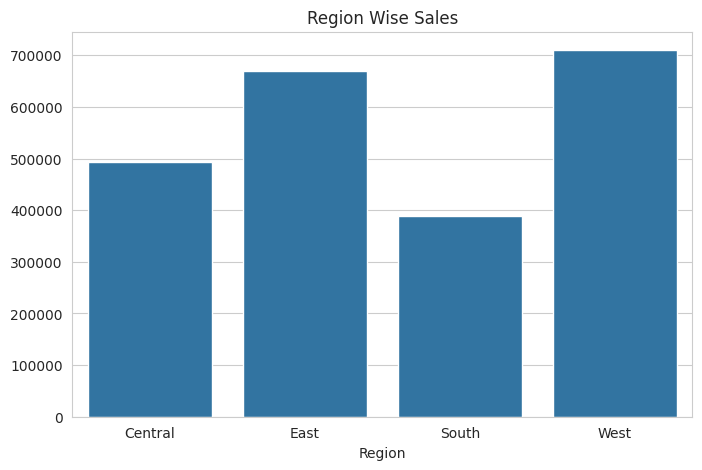

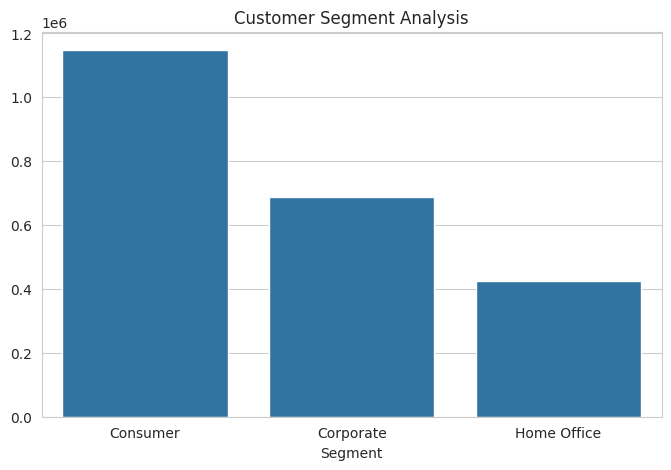

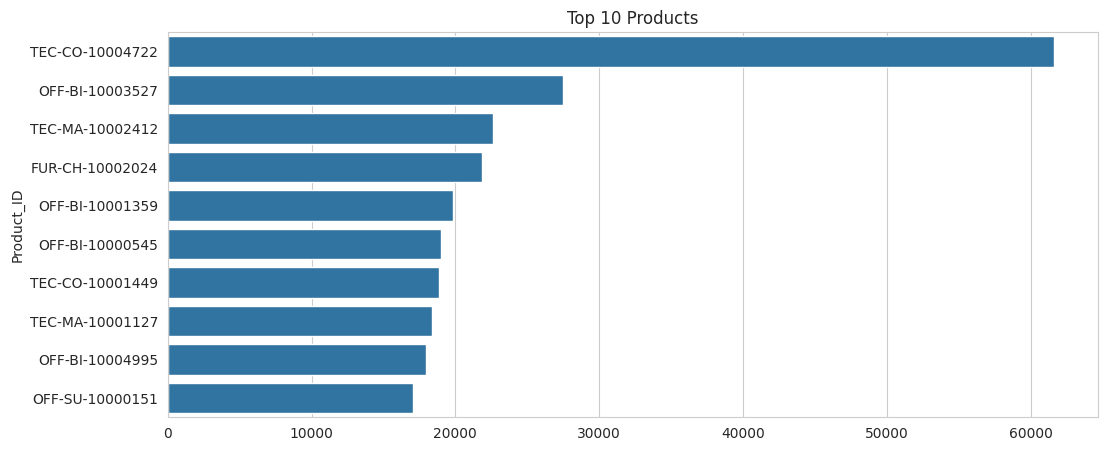

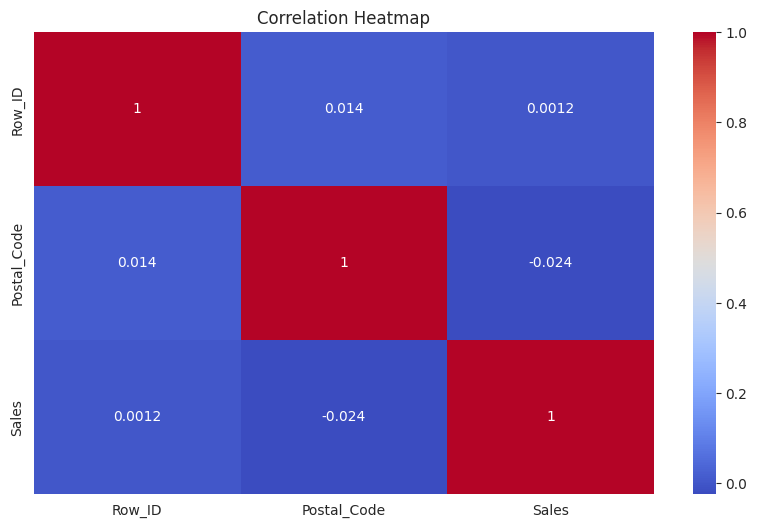


NumPy Insights
Mean : 230.7690594591837
Median : 54.489999999999995
Max : 22638.48
Min : 0.444
Std Dev : 626.619901988719

------ BUSINESS INSIGHTS ------
✔ Sales performance analyzed
✔ Customer segments evaluated
✔ Regional performance identified
✔ Product performance measured
✔ Correlation among variables explored
✔ Data-driven business recommendations generated


In [8]:
# ==================================
# SUPERSTORE SALES ANALYSIS
# ==================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv("/content/superstore_final_dataset (1).csv", encoding='latin1')

# Basic Info
print("Shape :", df.shape)
print("\nColumns :")
print(df.columns)

print("\nMissing Values")
print(df.isnull().sum())

# Remove Duplicates
df.drop_duplicates(inplace=True)

# ==================================
# NUMERIC ANALYSIS
# ==================================

print("\nSummary Statistics")
print(df.describe())

# ==================================
# SALES ANALYSIS
# ==================================

sales_col = [col for col in df.columns if 'sales' in col.lower()][0]

print("\nTotal Sales :", df[sales_col].sum())
print("Average Sales :", df[sales_col].mean())

# ==================================
# DISTRIBUTION OF SALES
# ==================================

plt.figure(figsize=(10,5))
sns.histplot(df[sales_col], kde=True)
plt.title("Sales Distribution")
plt.show()

# ==================================
# TOP CATEGORIES
# ==================================

if 'Category' in df.columns:

    top_cat = df.groupby('Category')[sales_col].sum().sort_values(ascending=False)

    plt.figure(figsize=(8,5))
    sns.barplot(x=top_cat.index,
                y=top_cat.values)

    plt.title("Sales by Category")
    plt.show()

# ==================================
# REGION ANALYSIS
# ==================================

if 'Region' in df.columns:

    region_sales = df.groupby('Region')[sales_col].sum()

    plt.figure(figsize=(8,5))
    sns.barplot(x=region_sales.index,
                y=region_sales.values)

    plt.title("Region Wise Sales")
    plt.show()

# ==================================
# SEGMENT ANALYSIS
# ==================================

if 'Segment' in df.columns:

    seg_sales = df.groupby('Segment')[sales_col].sum()

    plt.figure(figsize=(8,5))
    sns.barplot(x=seg_sales.index,
                y=seg_sales.values)

    plt.title("Customer Segment Analysis")
    plt.show()

# ==================================
# TOP 10 PRODUCTS
# ==================================

product_cols = [col for col in df.columns if 'product' in col.lower()]

if len(product_cols) > 0:

    top_products = (
        df.groupby(product_cols[0])[sales_col]
        .sum()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(12,5))
    sns.barplot(
        x=top_products.values,
        y=top_products.index
    )

    plt.title("Top 10 Products")
    plt.show()

# ==================================
# CORRELATION HEATMAP
# ==================================

num_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(num_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# ==================================
# NUMPY ANALYSIS
# ==================================

sales_array = np.array(df[sales_col])

print("\nNumPy Insights")
print("Mean :", np.mean(sales_array))
print("Median :", np.median(sales_array))
print("Max :", np.max(sales_array))
print("Min :", np.min(sales_array))
print("Std Dev :", np.std(sales_array))

# ==================================
# BUSINESS INSIGHTS
# ==================================

print("\n------ BUSINESS INSIGHTS ------")
print("✔ Sales performance analyzed")
print("✔ Customer segments evaluated")
print("✔ Regional performance identified")
print("✔ Product performance measured")
print("✔ Correlation among variables explored")
print("✔ Data-driven business recommendations generated")